# Chapter 14: Backtest Statistics

**AFML Ch. 14** -- Sharpe ratio adjustments and performance metrics.

A raw Sharpe ratio can be misleading when returns are non-normal or
when many strategies have been tested. This notebook covers the full
toolkit for evaluating backtests: the Probabilistic Sharpe Ratio (PSR)
accounts for higher moments, the Deflated Sharpe Ratio (DSR) corrects
for multiple testing, and drawdown analysis quantifies tail risk.

This notebook demonstrates:

- Sharpe ratio (annualized)
- Probabilistic Sharpe Ratio (PSR)
- Deflated Sharpe Ratio (DSR)
- Drawdown analysis
- HHI concentration
- Hit ratio

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import pymlfinance
import pymlfinance.polars

%matplotlib inline
np.random.seed(42)

## Generate Synthetic Strategy Returns

We simulate 500 daily returns with a small positive drift and inject
fat tails (20 random days with 3x returns) to make the distribution
more realistic.

In [2]:
n = 500
# Strategy with slight positive drift
returns = np.random.randn(n) * 0.01 + 0.0003
# Add some fat tails
returns[np.random.choice(n, 20, replace=False)] *= 3.0

print(f"Generated {n} daily returns")
print(f"  Mean: {np.mean(returns):.6f}, Std: {np.std(returns):.6f}")

Generated 500 daily returns
  Mean: 0.000353, Std: 0.011380


## Sharpe Ratio

The annualized Sharpe ratio scales mean return by volatility and the
square root of the number of periods per year.

In [3]:
sr = pymlfinance.backtesting.sharpe_ratio(returns)
sr_monthly = pymlfinance.backtesting.sharpe_ratio(returns, periods_per_year=12.0)
print(f"Annualized (daily):   {sr:.4f}")
print(f"Annualized (monthly): {sr_monthly:.4f}")

Annualized (daily):   0.4915
Annualized (monthly): 0.1073


## Higher Moments & Probabilistic Sharpe Ratio

Skewness and kurtosis affect the reliability of the Sharpe ratio
estimate. PSR gives the probability that the true Sharpe ratio exceeds
a benchmark, accounting for these higher moments.

In [4]:
skew = pymlfinance.core.skewness(returns)
kurt = pymlfinance.core.kurtosis(returns)
print(f"Skewness: {skew:.4f}")
print(f"Excess Kurtosis: {kurt:.4f}")

psr = pymlfinance.backtesting.probabilistic_sharpe_ratio(
    observed_sr=sr,
    benchmark_sr=0.0,
    n_observations=n,
    skewness=skew,
    kurtosis=kurt
)
print(f"\nPSR(SR > 0): {psr:.4f}")
print(f"Interpretation: {psr:.0%} probability that true SR > 0")

Skewness: 0.0888
Excess Kurtosis: 2.8062

PSR(SR > 0): 1.0000
Interpretation: 100% probability that true SR > 0


In [5]:
# PSR with different benchmarks
benchmarks = [0.0, 0.5, 1.0, 1.5]
psr_values = []
for bench in benchmarks:
    p = pymlfinance.backtesting.probabilistic_sharpe_ratio(
        sr, bench, n, skew, kurt
    )
    psr_values.append(p)
    print(f"PSR(SR > {bench}): {p:.4f}")

PSR(SR > 0.0): 1.0000
PSR(SR > 0.5): 0.4273
PSR(SR > 1.0): 0.0000
PSR(SR > 1.5): 0.0000


### Visualisation: Sharpe Ratio Comparison

A bar chart showing PSR at different benchmark levels. As the benchmark
increases, the probability of exceeding it drops.

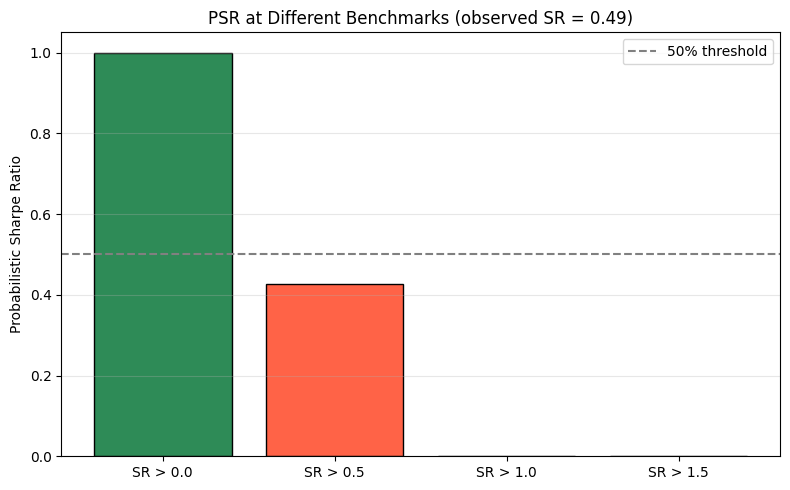

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["seagreen" if p > 0.5 else "tomato" for p in psr_values]
ax.bar([f"SR > {b}" for b in benchmarks], psr_values, color=colors, edgecolor="black")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, label="50% threshold")
ax.set_ylabel("Probabilistic Sharpe Ratio")
ax.set_title(f"PSR at Different Benchmarks (observed SR = {sr:.2f})")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Deflated Sharpe Ratio

When multiple strategies have been tested, DSR adjusts for the
selection bias. It penalises the Sharpe ratio based on the number
of trials and the variance of Sharpe ratios across trials.

In [7]:
n_trials = 20
trial_srs = [pymlfinance.backtesting.sharpe_ratio(
    np.random.randn(n) * 0.01 + 0.0002
) for _ in range(n_trials - 1)]
trial_srs.append(sr)  # include our strategy
sr_std = np.std(trial_srs)

dsr = pymlfinance.backtesting.deflated_sharpe_ratio(
    observed_sr=sr,
    sr_std=sr_std,
    n_observations=n,
    n_trials=n_trials,
    skewness=skew,
    kurtosis=kurt
)
print(f"After testing {n_trials} strategies:")
print(f"DSR = {dsr:.4f}")
print(f"(Accounts for multiple testing bias)")

After testing 20 strategies:
DSR = 0.0000
(Accounts for multiple testing bias)


## Drawdown Analysis

Drawdowns measure the peak-to-trough decline in cumulative returns.
Maximum drawdown and time under water are key risk metrics.

In [8]:
dd = pymlfinance.backtesting.compute_drawdowns(returns)
print(f"Max drawdown: {dd.max_drawdown:.4f} ({dd.max_drawdown:.2%})")
print(f"Max drawdown duration: {dd.max_drawdown_duration} bars")
dd_series = np.array(dd.drawdown_series)
print(f"Average drawdown: {np.mean(dd_series):.4f}")
tuw = np.array(dd.time_under_water)
print(f"Avg time under water: {np.mean(tuw):.1f} bars")

Max drawdown: 0.1880 (18.80%)
Max drawdown duration: 201 bars
Average drawdown: 0.0749
Avg time under water: 60.6 bars


### Visualisation: Cumulative Returns with Drawdown Overlay

The top panel shows cumulative returns; the bottom panel shows the
drawdown series (always negative or zero).

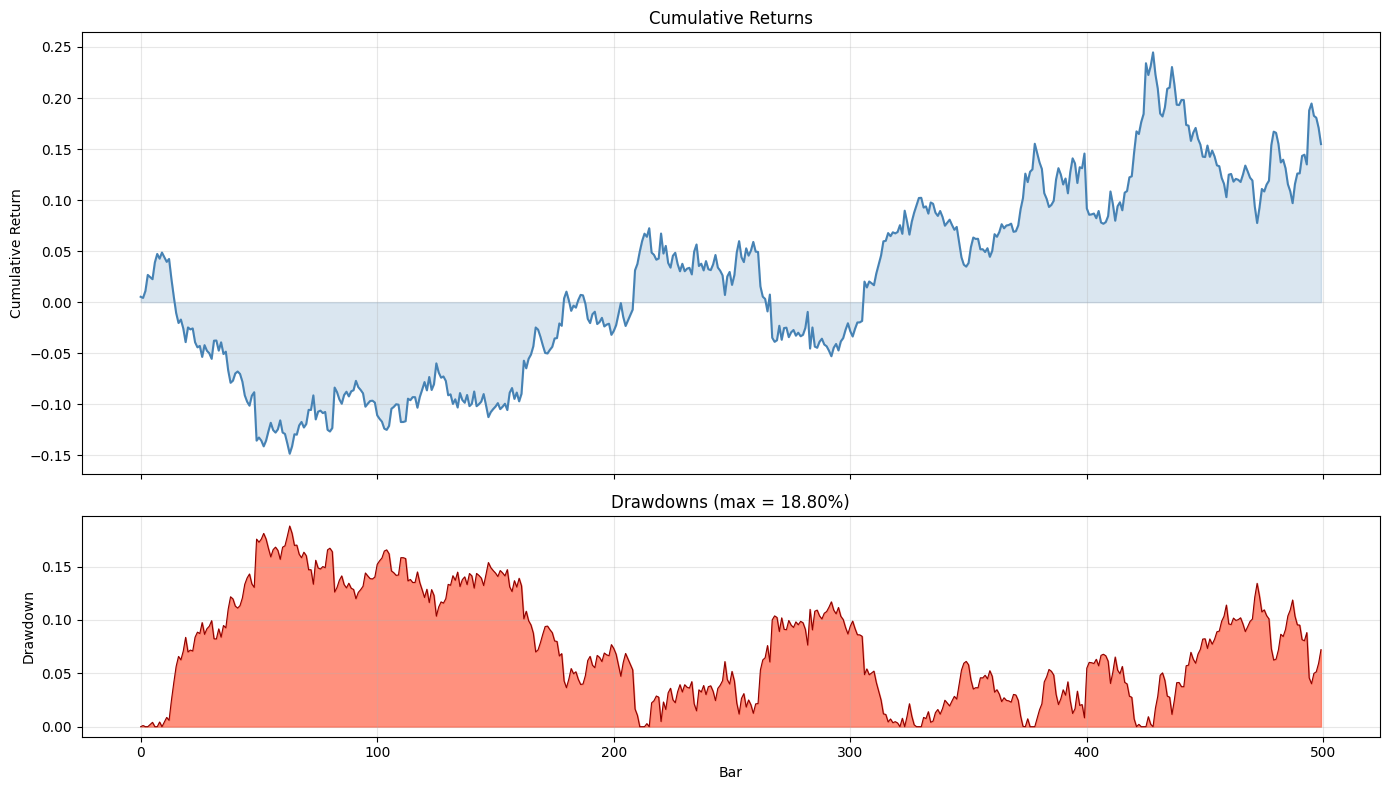

In [9]:
cum_returns = np.cumprod(1 + returns) - 1

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

# Cumulative returns
axes[0].plot(cum_returns, linewidth=1.5, color="steelblue")
axes[0].fill_between(range(len(cum_returns)), cum_returns, alpha=0.2, color="steelblue")
axes[0].set_ylabel("Cumulative Return")
axes[0].set_title("Cumulative Returns")
axes[0].grid(True, alpha=0.3)

# Drawdown series
axes[1].fill_between(range(len(dd_series)), dd_series, color="tomato", alpha=0.7)
axes[1].plot(dd_series, linewidth=0.8, color="darkred")
axes[1].set_xlabel("Bar")
axes[1].set_ylabel("Drawdown")
axes[1].set_title(f"Drawdowns (max = {dd.max_drawdown:.2%})")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Hit Ratio

The hit ratio (win rate) is the fraction of returns that are positive.
A high hit ratio does not guarantee profitability if losses are large.

In [10]:
hr = pymlfinance.backtesting.hit_ratio(returns)
print(f"Win rate: {hr:.4f} ({hr:.1%})")

Win rate: 0.5220 (52.2%)


## HHI Concentration

The Herfindahl-Hirschman Index measures concentration. Applied to
absolute returns, it shows whether P&L is driven by a few large bets
(high HHI) or distributed evenly across time (low HHI).

In [11]:
hhi_val = pymlfinance.backtesting.hhi(np.abs(returns) / np.sum(np.abs(returns)))
pos_hhi, neg_hhi = pymlfinance.backtesting.hhi_concentration(returns)
print(f"HHI of |returns|: {hhi_val:.6f}")
print(f"Positive return HHI: {pos_hhi:.6f}")
print(f"Negative return HHI: {neg_hhi:.6f}")
print(f"(Lower HHI = more diversified across time)")

HHI of |returns|: 0.003605
Positive return HHI: 0.007146
Negative return HHI: 0.007260
(Lower HHI = more diversified across time)


## Polars API

The same statistics are available as Polars expressions via the `.ml`
namespace for efficient column-wise computation.

In [12]:
df = pl.DataFrame({"returns": returns})
stats = df.select(
    pl.col("returns").ml.sharpe_ratio().alias("sharpe"),
    pl.col("returns").ml.hit_ratio().alias("hit_ratio"),
    pl.col("returns").ml.hhi().alias("hhi"),
)
print(stats)

dd_df = df.with_columns(
    pl.col("returns").ml.compute_drawdowns().alias("drawdown"),
)
print(f"Drawdown series (first 5): {dd_df['drawdown'].head(5).to_list()}")

shape: (1, 3)
┌─────────┬───────────┬──────────┐
│ sharpe  ┆ hit_ratio ┆ hhi      │
│ ---     ┆ ---       ┆ ---      │
│ f64     ┆ f64       ┆ f64      │
╞═════════╪═══════════╪══════════╡
│ 0.49153 ┆ 0.522     ┆ 0.003605 │
└─────────┴───────────┴──────────┘


Drawdown series (first 5): [0.0, 0.0010826430117118755, 0.0, 0.0, 0.0020415337472334213]


## Exercises

1. Increase `n_trials` in DSR and observe how it penalises the Sharpe ratio.
2. Compare PSR for strategies with different skewness/kurtosis.
3. Generate a strategy with high hit ratio but negative Sharpe (large losses).